In [1]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9777777777777777

In [6]:
# SVM Classifier for IRIS Dataset (Linear & RBF Kernel)
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load IRIS dataset
iris = pd.read_csv("iris.csv")

# Display dataset
print(iris.head())

# Features and target
X = iris.drop("species", axis=1)
y = iris["species"]

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# SVM using RBF kernel
# -----------------------------
rbf_model = SVC(kernel='rbf')

rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

print("Confusion Matrix (RBF):")
print(confusion_matrix(y_test, y_pred_rbf))


# -----------------------------
# SVM using Linear kernel
# -----------------------------
linear_model = SVC(kernel='linear')

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

print("Confusion Matrix (Linear):")
print(confusion_matrix(y_test, y_pred_linear))

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  
Accuracy: 0.8545
Confusion Matrix:
[[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0   1   0]
 [  1 133   0   3   0   0   0   5   0   0   1   0   0   1   0   1   0   6
    1  

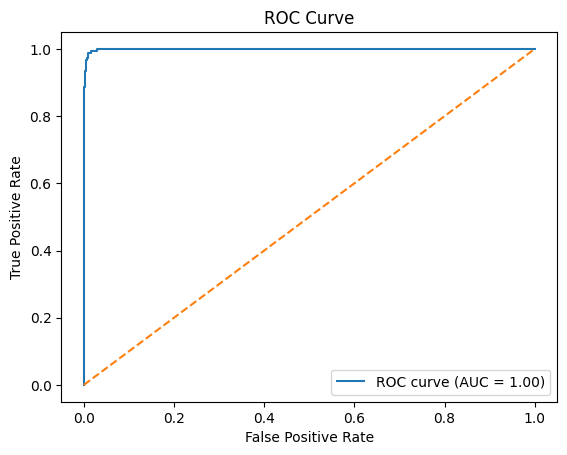

AUC Score: 0.9991704412172207


In [7]:
# SVM Classifier for Letter Recognition Dataset + ROC + AUC
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Load dataset
letter = pd.read_csv("letter-recognition.csv")

print(letter.head())

# Features and target
X = letter.iloc[:,1:]   # features
y = letter.iloc[:,0]    # letter label

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
model = SVC(kernel='linear', probability=True)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# -----------------------------
# ROC Curve and AUC Score
# -----------------------------

# Convert labels to binary for ROC
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_score = model.predict_proba(X_test)

# ROC for first class
fpr, tpr, _ = roc_curve(y_test_bin[:,0], y_score[:,0])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)